## ⚠️ Important — Do Not Rerun This Notebook

This notebook pulls live data from the OpenAlex API. If rerun, results may differ 
from the saved dataset because:

- OpenAlex continuously updates citation counts, metadata and paper records
- New papers are added and existing records are corrected over time

**The raw data has already been pulled and saved to:**
`data/OpenAlex/openalex_ai_papers_full.csv`

**Date of original data pull:** 16 March 2026

To reproduce this project, use the saved CSV directly — do not rerun this notebook.

# OpenAlex API

Python client library for the OpenAlex API - PyAlex  
OpenAlex is a free, open catalog of the world's scholarly research — covering academic papers, authors, institutions, journals, and concepts. It's a successor to Microsoft Academic Graph.  
PyAlex makes it easy to query the OpenAlex API from Python without having to manually handle HTTP requests, pagination, or response parsing. Key features include:

Search and filter academic works, authors, venues, institutions, and concepts

Pythonic interface — results come back as easy-to-use Python objects

Pagination support built in

Polite pool support — lets you identify yourself to OpenAlex for better rate limits

In [8]:
!pip install pyalex pandas pyarrow

In [2]:
import pyalex
from pyalex import Works, Authors, Topics, Fields, Subfields
import pandas as pd
from itertools import chain


In [3]:
from dotenv import load_dotenv
import os

load_dotenv()

# My credentials are stored in the .env file, so I can load them from there. --- IGNORE ---
pyalex.config.email = os.getenv("OPENALEX_EMAIL")
pyalex.config.api_key = os.getenv("OPENALEX_API_KEY")

In [ ]:

# Optional but recommended — handles failures gracefully
pyalex.config.max_retries = 3
pyalex.config.retry_backoff_factor = 0.5
pyalex.config.retry_http_codes = [429, 500, 503]

## Explore the avaliable data

The topic is Computer science and AI research papers, first checking what fields avaliable in the API and look for the field number of CS

In [11]:
from pyalex import Fields

all_fields = Fields().get()

for field in all_fields:
    print(f"{field['id'].split('/')[-1]}  |  {field['display_name']}")

22  |  Engineering
33  |  Social Sciences
27  |  Medicine
12  |  Arts and Humanities
31  |  Physics and Astronomy
17  |  Computer Science
11  |  Agricultural and Biological Sciences
13  |  Biochemistry, Genetics and Molecular Biology
23  |  Environmental Science
20  |  Economics, Econometrics and Finance
25  |  Materials Science
14  |  Business, Management and Accounting
32  |  Psychology
36  |  Health Professions
19  |  Earth and Planetary Sciences
16  |  Chemistry
26  |  Mathematics
28  |  Neuroscience
18  |  Decision Sciences
24  |  Immunology and Microbiology
21  |  Energy
29  |  Nursing
30  |  Pharmacology, Toxicology and Pharmaceutics
35  |  Dentistry
15  |  Chemical Engineering


CS field has number 17, so let's look at the subfields in the CS category

In [12]:
from pyalex import Subfields

cs_subfields = Subfields().filter(field={"id": "17"}).get()

for sf in cs_subfields:
    print(f"{sf['id'].split('/')[-1]}  |  {sf['display_name']}")

1702  |  Artificial Intelligence
1710  |  Information Systems
1705  |  Computer Networks and Communications
1707  |  Computer Vision and Pattern Recognition
1703  |  Computational Theory and Mathematics
1706  |  Computer Science Applications
1711  |  Signal Processing
1708  |  Hardware and Architecture
1709  |  Human-Computer Interaction
1704  |  Computer Graphics and Computer-Aided Design
1712  |  Software


AI subfield has number 1702, let's check what topics are avaliable in the AI subfield

In [13]:
from pyalex import Topics

print("=== Artificial Intelligence (1702) ===")

topics = Topics().filter(subfield={"id": "1702"}).get()

for topic in topics:
    print(f"{topic['id'].split('/')[-1]}  |  {topic['display_name']}  |  works: {topic['works_count']:,}")

=== Artificial Intelligence (1702) ===
T12157  |  Geochemistry and Geologic Mapping  |  works: 3,955,424
T13650  |  Computational Physics and Python Applications  |  works: 411,994
T10181  |  Natural Language Processing Techniques  |  works: 291,459
T14335  |  Educational Robotics and Engineering  |  works: 258,211
T10320  |  Neural Networks and Applications  |  works: 250,050
T13398  |  Data Analysis with R  |  works: 246,401
T13734  |  Advanced Computational Techniques and Applications  |  works: 179,996
T10215  |  Semantic Web and Ontologies  |  works: 171,074
T10028  |  Topic Modeling  |  works: 160,967
T13623  |  Linguistic Studies and Language Acquisition  |  works: 157,496
T10020  |  Quantum Information and Cryptography  |  works: 149,032
T10682  |  Quantum Computing Algorithms and Architecture  |  works: 115,654
T10126  |  Logic, programming, and type systems  |  works: 108,256
T10201  |  Speech Recognition and Synthesis  |  works: 94,196
T13559  |  Edcuational Technology Syste

## Define what type of data for the pull

Some topics are quite broad and related to other fields such as medicine, we want to focus specifically on AI in CS topics, so we select 10 topics related to CS  
We confirm that the topics are in CS field and AI subfield

In [14]:
topic_ids = [
    "T10181", "T10320", "T10028", "T10201", "T10664",
    "T11512", "T11975", "T10100", "T10764", "T10682"
]

for tid in topic_ids:
    topic = Topics()[tid]
    field = topic["field"]["display_name"]
    subfield = topic["subfield"]["display_name"]
    print(f"{tid}  |  {topic['display_name'][:45]:<45}  |  {field}  |  {subfield}")

T10181  |  Natural Language Processing Techniques         |  Computer Science  |  Artificial Intelligence
T10320  |  Neural Networks and Applications               |  Computer Science  |  Artificial Intelligence
T10028  |  Topic Modeling                                 |  Computer Science  |  Artificial Intelligence
T10201  |  Speech Recognition and Synthesis               |  Computer Science  |  Artificial Intelligence
T10664  |  Sentiment Analysis and Opinion Mining          |  Computer Science  |  Artificial Intelligence
T11512  |  Anomaly Detection Techniques and Applications  |  Computer Science  |  Artificial Intelligence
T11975  |  Evolutionary Algorithms and Applications       |  Computer Science  |  Artificial Intelligence
T10100  |  Metaheuristic Optimization Algorithms Researc  |  Computer Science  |  Artificial Intelligence
T10764  |  Privacy-Preserving Technologies in Data        |  Computer Science  |  Artificial Intelligence
T10682  |  Quantum Computing Algorithms and Ar

Let's see what kind of publications are avaliable on the example of one topic.

In [15]:

# Get a sample of works to see available types
types = (
    Works()
    .filter(primary_topic={"id": "T10181"})
    .group_by("type")
    .get()
)

for t in types:
    print(f"{t['key']}  |  count: {t['count']:,}")

https://openalex.org/types/article  |  count: 158,631
https://openalex.org/types/book-chapter  |  count: 28,587
https://openalex.org/types/preprint  |  count: 26,344
https://openalex.org/types/dataset  |  count: 6,660
https://openalex.org/types/dissertation  |  count: 6,503
https://openalex.org/types/book  |  count: 5,673
https://openalex.org/types/libguides  |  count: 5,254
https://openalex.org/types/paratext  |  count: 1,500
https://openalex.org/types/other  |  count: 989
https://openalex.org/types/report  |  count: 641
https://openalex.org/types/review  |  count: 552
https://openalex.org/types/reference-entry  |  count: 366
https://openalex.org/types/peer-review  |  count: 300
https://openalex.org/types/standard  |  count: 277
https://openalex.org/types/letter  |  count: 133
https://openalex.org/types/erratum  |  count: 128
https://openalex.org/types/editorial  |  count: 90
https://openalex.org/types/retraction  |  count: 4
https://openalex.org/types/supplementary-materials  |  coun

Articles are the highest volume and also this is what we want to explore in our project for the publications

Set the selected topics in a dictionary

In [16]:
topics = {
    "T10181": "Natural Language Processing Techniques",
    "T10320": "Neural Networks and Applications",
    "T10028": "Topic Modeling",
    "T10201": "Speech Recognition and Synthesis",
    "T10664": "Sentiment Analysis and Opinion Mining",
    "T11512": "Anomaly Detection Techniques and Applications",
    "T11975": "Evolutionary Algorithms and Applications",
    "T10100": "Metaheuristic Optimization Algorithms Research",
    "T10764": "Privacy-Preserving Technologies in Data",
    "T10682": "Quantum Computing Algorithms and Architecture",
}

For the analysis and reliable ML model I will collect the articles for the last 10 years (2015-2024) and I filter it by type "article" to exclude other type of publications  
Let's check the volume of the articles per topic in each year

In [17]:
import matplotlib.pyplot as plt
import pandas as pd
from pyalex import Works


# Store counts
rows = []
for topic_id, topic_name in topics.items():
    print(f"\n{topic_name}")
    for year in range(2015, 2025):
        count = Works().filter(
            primary_topic={"id": topic_id},
            publication_year=str(year),
            type="article",
            is_retracted=False
        ).count()
        print(f"  {year}: {count:,}")
        rows.append({
            "topic_name": topic_name,
            "year": year,
            "paper_count": count
        })

# Build dataframe
counts_df = pd.DataFrame(rows)




Natural Language Processing Techniques
  2015: 5,566
  2016: 5,925
  2017: 5,300
  2018: 5,614
  2019: 5,669
  2020: 5,908
  2021: 4,968
  2022: 4,201
  2023: 4,934
  2024: 7,368

Neural Networks and Applications
  2015: 3,134
  2016: 3,336
  2017: 3,362
  2018: 3,913
  2019: 4,229
  2020: 3,753
  2021: 3,273
  2022: 2,627
  2023: 3,004
  2024: 6,131

Topic Modeling
  2015: 1,796
  2016: 2,202
  2017: 2,480
  2018: 3,533
  2019: 4,546
  2020: 5,521
  2021: 6,708
  2022: 6,484
  2023: 8,709
  2024: 7,674

Speech Recognition and Synthesis
  2015: 1,831
  2016: 1,937
  2017: 1,739
  2018: 1,934
  2019: 2,071
  2020: 2,062
  2021: 2,135
  2022: 2,225
  2023: 2,624
  2024: 3,068

Sentiment Analysis and Opinion Mining
  2015: 1,377
  2016: 1,660
  2017: 1,798
  2018: 2,232
  2019: 2,502
  2020: 2,847
  2021: 3,218
  2022: 3,214
  2023: 3,722
  2024: 3,865

Anomaly Detection Techniques and Applications
  2015: 1,186
  2016: 1,391
  2017: 1,601
  2018: 2,021
  2019: 2,478
  2020: 2,771
  2021

We can see that the amount of articles per topic and years vary significantly, so lets visualise the trends to have a clear overview

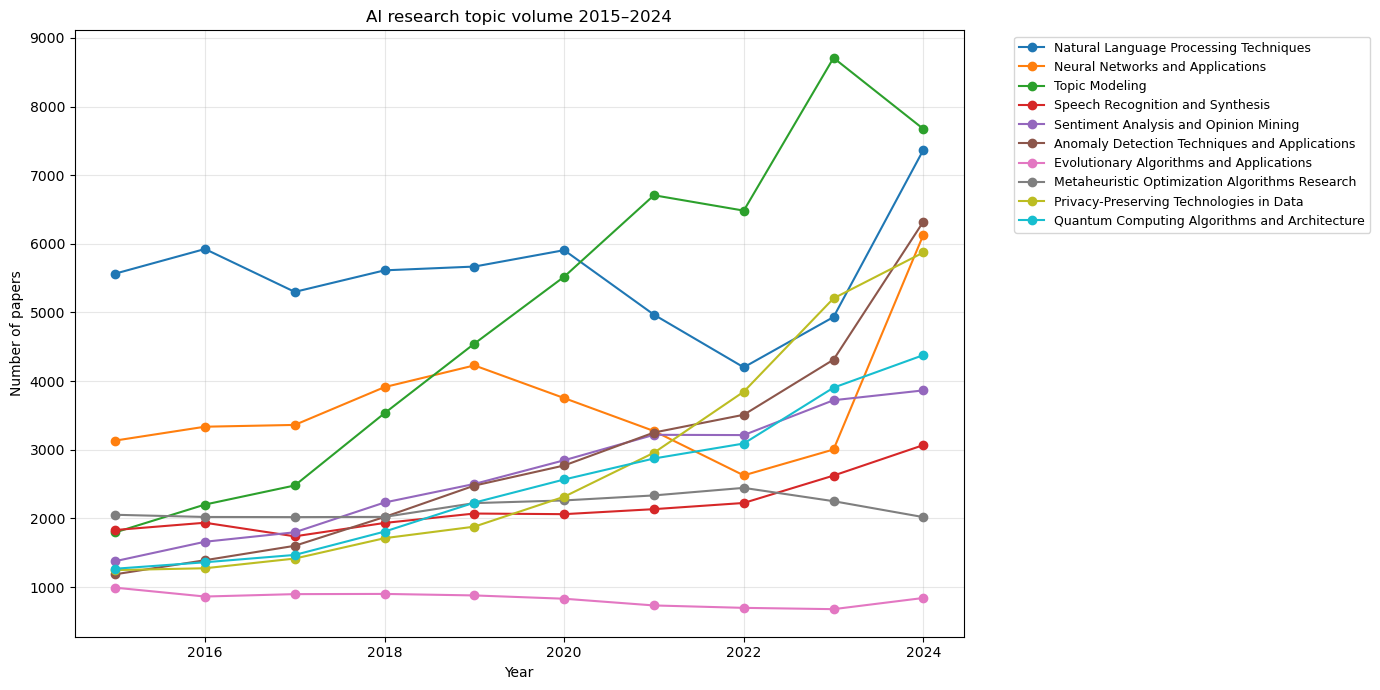

In [18]:
# Plot
fig, ax = plt.subplots(figsize=(14, 7))

for topic in counts_df["topic_name"].unique():
    topic_data = counts_df[counts_df["topic_name"] == topic]
    ax.plot(
        topic_data["year"],
        topic_data["paper_count"],
        marker="o",
        label=topic
    )

ax.set_xlabel("Year")
ax.set_ylabel("Number of papers")
ax.set_title("AI research topic volume 2015–2024")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../data/OpenAlex/topic_volume_per_year.png", dpi=150)
plt.show()

This chart clearly shows how some topics rapidly grow through the years and other remain stable

Now, I want to pull all these articles for the 10 topics for years 2015-2024 and I need to decide what columns I want to pull.  
To do that, I will pull one article from one of the topics for the overview of avaliable data per article.

In [19]:
# Pull one paper from your first topic to see all available fields
sample = (
    Works()
    .filter(
        primary_topic={"id": "T10181"},
        publication_year="2023",
        type="article"
    )
    .get()[0]  # just the first result
)

for key, value in sample.items():
    print(f"{key}: {value}")

id: https://openalex.org/W4385572634
doi: https://doi.org/10.18653/v1/2023.acl-long.754
title: Self-Instruct: Aligning Language Models with Self-Generated Instructions
display_name: Self-Instruct: Aligning Language Models with Self-Generated Instructions
publication_year: 2023
publication_date: 2023-01-01
ids: {'openalex': 'https://openalex.org/W4385572634', 'doi': 'https://doi.org/10.18653/v1/2023.acl-long.754'}
language: en
primary_location: {'id': 'doi:10.18653/v1/2023.acl-long.754', 'is_oa': True, 'landing_page_url': 'https://doi.org/10.18653/v1/2023.acl-long.754', 'pdf_url': 'https://aclanthology.org/2023.acl-long.754.pdf', 'source': None, 'license': 'cc-by', 'license_id': 'https://openalex.org/licenses/cc-by', 'version': 'publishedVersion', 'is_accepted': True, 'is_published': True, 'raw_source_name': 'Proceedings of the 61st Annual Meeting of the Association for Computational Linguistics (Volume 1: Long Papers)', 'raw_type': 'proceedings-article'}
type: article
indexed_in: ['cro

This overview shows me exact fields avaliable for the article.
Based on this I make a selection.
Some of the columns have nested JSON files, these fields will be flattened at the pull and extracted only necessary columns from nested source.


## Data pull overview

### Final Fields Overview — What We Pull and Why

---

### Fields Pulled Directly From OpenAlex

**`id`**
Unique OpenAlex identifier for each paper e.g. `W2741809807`. Used as a row identifier only — not a feature in ML. Needed to avoid duplicate rows and for EDA spot checks.

**`title`**
Full title of the paper e.g. *"Attention Is All You Need"*. Not used in ML. Used for EDA spot checks to verify the data makes sense — confirming an NLP paper actually looks like an NLP paper.

**`publication_year`**
The year the paper was published. Core time feature in ML — tells the model when the paper appeared, which matters because citation patterns and research culture change over time. Used as train/test split boundary: train 2015–2021, test 2022–2024.

**`language`**
Language the paper is written in e.g. `en`, `zh`, `de`. Used as a feature — language distribution varies by topic and year, and non-English papers tend to have different citation patterns. We decided not to filter to English only so as to include Chinese research which represents ~15% of CS/AI output.

**`cited_by_count`**
Total citations the paper has received up to the snapshot date. Cannot be used as a feature — data leakage because it accumulates after publication and is unknown at publication time. Kept in dataset for reference and EDA only.

**`referenced_works_count`**
Number of references cited by this paper. Available at publication time — used as a feature. Papers that cite more prior work tend to be more thorough and connected to the research community, which correlates with impact.

**`fwci`**
Field-Weighted Citation Impact — a normalised citation score that controls for field size and paper age. Cannot be used as a feature — data leakage because it is calculated from citations after publication. Kept for reference only.

**`institutions_distinct_count`**
Number of unique institutions that contributed authors to this paper. Available at publication time — used as a feature. Papers from multiple institutions signal broader collaboration which consistently correlates with higher impact.

**`countries_distinct_count`**
Number of unique countries represented among the authors. Available at publication time — used as a feature. International collaboration is one of the strongest predictors of research impact across all fields.

---

### Fields Pulled and Flattened

**`primary_location`** — nested dict describing where the paper was published

Extracts:
- `publication_type` — whether the paper appeared in a `proceedings-article` (conference) or `journal-article`. Critical feature for CS/AI where top conferences like NeurIPS, ACL and CVPR carry more prestige than journals — conference papers in AI tend to be more cutting-edge and highly cited.

Raw column dropped after extraction.

---

**`open_access`** — nested dict describing the open access status

Extracts:
- `is_oa` — simple True/False whether the paper is freely available anywhere. Open access papers consistently receive 50–200% more citations than paywalled papers in CS/AI — important feature and confounder to control for.
- `oa_status` — more granular than `is_oa`: `gold` (paid OA journal), `diamond` (free OA journal), `green` (self-archived on arXiv etc.), `closed`. Different OA routes have different citation implications.

Raw column dropped after extraction.

---

**`authorships`** — nested list, one item per author with name, institutions and countries

Extracts:
- `authors_count` — number of authors on the paper via `len(authorships)`. Available at publication time. Larger teams tend to appear in more established collaborative fields — solo papers are more common in theoretical work while applied emerging topics tend to have larger author lists.

Raw column dropped after extraction.

---

**`citation_normalized_percentile`** — nested dict describing global citation rank

Extracts:
- `citation_top_1_percent` — True/False whether this paper is in the top 1% most cited globally. Cannot be used as a feature — data leakage. Kept for reference only.
- `citation_top_10_percent` — True/False whether this paper is in the top 10% most cited globally. **This is your target variable `is_high_impact`.** Cannot be used as a feature.

Raw column dropped after extraction.

---

**`cited_by_percentile_year`** — nested dict describing citation rank within publication year

Extracts:
- `cited_by_percentile_year_min` — lower bound of citation percentile among papers published the same year e.g. 99 means top 1% of that year. Cannot be used as a feature — data leakage. Kept for reference only.
- `cited_by_percentile_year_max` — upper bound of same percentile range. Cannot be used as a feature — data leakage. Kept for reference only.

Raw column dropped after extraction.

---

**`counts_by_year`** — nested list, one item per year showing citations received that year

Extracts:
- `first_year_citations` — citations received in the year immediately after publication (`publication_year + 1`). Your strongest early signal feature — a paper cited heavily in year 1 is a strong indicator of high eventual impact, and this is knowable relatively early before full citation counts accumulate.

Raw column dropped after extraction.

---

**`keywords`** — nested list of keyword objects each with a name and relevance score

Extracts:
- `keyword_count` — number of keywords assigned to the paper via `len(keywords)`. Papers with more keywords tend to be more interdisciplinary and cross-domain — a signal of emerging topics that bridge multiple areas, which tends to correlate with higher impact.

Raw column dropped after extraction.

---

**`primary_topic`** — nested dict describing the paper's primary research topic

Extracts:
- `primary_topic_score` — confidence score (0–1) for how strongly OpenAlex classified this paper into its primary topic. A score of 0.94 means the paper is very focused on its topic. Highly focused papers tend to be more methodologically rigorous and impactful. Also helps identify papers that sit on the boundary between topics.

Raw column dropped after extraction.

---

### Fields Added Manually in Pull Function

**`topic_id`**
The OpenAlex topic ID used to pull this batch of papers e.g. `T10181`. Added manually with `df["topic_id"] = topic_id`. Redundant — covered by `topic_name`. Drop in Week 2.

**`topic_name`**
Human-readable topic name e.g. `"Natural Language Processing Techniques"`. Added manually with `df["topic_name"] = topic_name`. Used as a feature — different topics have very different impact patterns. Encode in Week 2 before feeding into XGBoost.

---

### Fields Skipped — and Why

| Field | Reason skipped |
|---|---|
| `abstract_inverted_index` | Scrambled text requiring complex NLP reconstruction — out of scope |
| `referenced_works` | List of paper IDs only — not useful without extra API calls |
| `related_works` | Same — IDs only |
| `locations` / `locations_count` / `best_oa_location` | Duplicate of `primary_location` — already covered |
| `concepts` | Deprecated by OpenAlex — replaced by `keywords` |
| `mesh` | Empty for CS papers — medical terms only |
| `sustainable_development_goals` | Not relevant to impact prediction |
| `awards` / `funders` | Complex nested JSON, not available at publication time for prediction |
| `biblio` | Page numbers — not useful for ML |
| `ids` | Duplicate identifiers — already have `id` |
| `indexed_in` | Which databases index the paper — not useful |
| `apc_list` / `apc_paid` | Mostly null for CS papers |
| `updated_date` / `created_date` | OpenAlex admin dates — not useful |
| `is_retracted` | Filtered out at pull time |
| `is_paratext` / `is_xpac` | Internal OpenAlex flags — not useful |
| `display_name` | Same as `title` — duplicate |
| `doi` | Identifier only — not useful for ML |
| `type` | Filtered to `article` at pull time |
| `topics` | Secondary topics — covered by `primary_topic` |
| `license` | Redundant — already captured by `is_oa` and `oa_status` |
| `second_year_citations` | Marginal value — many 2023–2024 papers have no year 2 data yet |

---

### Final 22 Columns to Pull

| Column | Source | Use in ML | Notes |
|---|---|---|---|
| `id` | direct | ❌ identifier | |
| `title` | direct | ❌ EDA only | |
| `publication_year` | direct | ✅ feature | train/test split boundary |
| `language` | direct | ✅ feature | encode in Week 2 |
| `cited_by_count` | direct | ❌ leaky | reference only |
| `referenced_works_count` | direct | ✅ feature | |
| `fwci` | direct | ❌ leaky | reference only |
| `institutions_distinct_count` | direct | ✅ feature | |
| `countries_distinct_count` | direct | ✅ feature | |
| `publication_type` | primary_location | ✅ feature | encode in Week 2 |
| `is_oa` | open_access | ✅ feature | |
| `oa_status` | open_access | ✅ feature | encode in Week 2 |
| `authors_count` | authorships | ✅ feature | |
| `citation_top_1_percent` | citation_normalized_percentile | ❌ leaky | reference only |
| `citation_top_10_percent` | citation_normalized_percentile | 🎯 target | `is_high_impact` |
| `cited_by_percentile_year_min` | cited_by_percentile_year | ❌ leaky | reference only |
| `cited_by_percentile_year_max` | cited_by_percentile_year | ❌ leaky | reference only |
| `keyword_count` | keywords | ✅ feature | |
| `primary_topic_score` | primary_topic | ✅ feature | |
| `first_year_citations` | counts_by_year | ✅ feature | strongest signal |
| `topic_id` | manual | ❌ redundant | drop in Week 2 |
| `topic_name` | manual | ✅ feature | encode in Week 2 |

## Data pull

In [20]:
def pull_topic(topic_id, topic_name, year_start=2015, year_end=2024):
    
    all_records = []
    
    for year in range(year_start, year_end + 1):
        
        query = (
            Works()
            .filter(
                primary_topic={"id": topic_id},
                publication_year=str(year),
                type="article",
                is_retracted=False
            )
            .select([
                "id",
                "title",
                "publication_year",
                "language",
                "cited_by_count",
                "cited_by_percentile_year",
                "referenced_works_count",
                "fwci",
                "citation_normalized_percentile",
                "counts_by_year",
                "authorships",
                "open_access",
                "institutions_distinct_count",
                "countries_distinct_count",
                "keywords",
                "primary_location",
                "primary_topic",
            ])
        )
        
        records = []
        for page in query.paginate(per_page=200, n_max=None):
            records.extend(page)
        
        all_records.extend(records)
        print(f"  {year}: {len(records):,} papers")
    
    df = pd.DataFrame(all_records)
    
    # Flatten nested columns
    df["publication_type"]              = df["primary_location"].apply(lambda x: x.get("raw_type") if isinstance(x, dict) else "unknown")
    df["is_oa"]                         = df["open_access"].apply(lambda x: x.get("is_oa") if isinstance(x, dict) else None)
    df["oa_status"]                     = df["open_access"].apply(lambda x: x.get("oa_status") if isinstance(x, dict) else None)
    df["authors_count"]                 = df["authorships"].apply(lambda x: len(x) if isinstance(x, list) else 0)
    df["citation_top_1_percent"]        = df["citation_normalized_percentile"].apply(lambda x: x.get("is_in_top_1_percent") if isinstance(x, dict) else None)
    df["citation_top_10_percent"]       = df["citation_normalized_percentile"].apply(lambda x: x.get("is_in_top_10_percent") if isinstance(x, dict) else None)
    df["cited_by_percentile_year_min"]  = df["cited_by_percentile_year"].apply(lambda x: x.get("min") if isinstance(x, dict) else None)
    df["cited_by_percentile_year_max"]  = df["cited_by_percentile_year"].apply(lambda x: x.get("max") if isinstance(x, dict) else None)
    df["keyword_count"]                 = df["keywords"].apply(lambda x: len(x) if isinstance(x, list) else 0)
    df["primary_topic_score"] = df["primary_topic"].apply(
        lambda x: x.get("score") if isinstance(x, dict) else None
        )
    df["first_year_citations"]          = df.apply(
        lambda row: next(
            (item["cited_by_count"] for item in row["counts_by_year"]
             if isinstance(row["counts_by_year"], list) and item["year"] == row["publication_year"] + 1),
            0
        ), axis=1
    )
    
    # Drop raw nested columns
    df = df.drop(columns=[
        "primary_location",
        "open_access",
        "authorships",
        "citation_normalized_percentile",
        "cited_by_percentile_year",
        "counts_by_year",
        "keywords",
        "primary_topic",
    ])
    
    df["topic_id"]   = topic_id
    df["topic_name"] = topic_name
    print(f"✅ {topic_name}: {len(df):,} papers total\n")
    return df

In [21]:
dfs = []

for topic_id, topic_name in topics.items():
    df = pull_topic(topic_id, topic_name)
    dfs.append(df)

master_df = pd.concat(dfs, ignore_index=True)
print(f"\n📊 Total papers: {len(master_df):,}")

  2015: 5,566 papers
  2016: 5,925 papers
  2017: 5,300 papers
  2018: 5,614 papers
  2019: 5,669 papers
  2020: 5,908 papers
  2021: 4,968 papers
  2022: 4,201 papers
  2023: 4,934 papers
  2024: 7,368 papers
✅ Natural Language Processing Techniques: 55,453 papers total

  2015: 3,134 papers
  2016: 3,336 papers
  2017: 3,362 papers
  2018: 3,913 papers
  2019: 4,229 papers
  2020: 3,753 papers
  2021: 3,273 papers
  2022: 2,627 papers
  2023: 3,004 papers
  2024: 6,131 papers
✅ Neural Networks and Applications: 36,762 papers total

  2015: 1,796 papers
  2016: 2,202 papers
  2017: 2,480 papers
  2018: 3,533 papers
  2019: 4,546 papers
  2020: 5,521 papers
  2021: 6,708 papers
  2022: 6,484 papers
  2023: 8,709 papers
  2024: 7,674 papers
✅ Topic Modeling: 49,653 papers total

  2015: 1,831 papers
  2016: 1,937 papers
  2017: 1,739 papers
  2018: 1,934 papers
  2019: 2,071 papers
  2020: 2,062 papers
  2021: 2,135 papers
  2022: 2,225 papers
  2023: 2,624 papers
  2024: 3,068 papers
✅

## Save csv

In [22]:
data_dir = "../data/OpenAlex"

master_df.to_csv(f"{data_dir}/openalex_ai_papers_full.csv", index=False)
print(f"💾 Saved to {data_dir}")

💾 Saved to ../data/OpenAlex


In [23]:
print(master_df.shape)
print("\nPapers per topic:")
print(master_df["topic_name"].value_counts())
print("\nPapers per year:")
print(master_df["publication_year"].value_counts().sort_index())
print("\nMissing values:")
print(master_df.isnull().sum())

(301406, 22)

Papers per topic:
topic_name
Natural Language Processing Techniques            55453
Topic Modeling                                    49653
Neural Networks and Applications                  36762
Anomaly Detection Techniques and Applications     28845
Privacy-Preserving Technologies in Data           27727
Sentiment Analysis and Opinion Mining             26435
Quantum Computing Algorithms and Architecture     24949
Metaheuristic Optimization Algorithms Research    21650
Speech Recognition and Synthesis                  21626
Evolutionary Algorithms and Applications           8306
Name: count, dtype: int64

Papers per year:
publication_year
2015    20448
2016    21969
2017    22079
2018    25689
2019    28706
2020    30837
2021    32450
2022    32340
2023    39346
2024    47542
Name: count, dtype: int64

Missing values:
id                                  0
title                               0
publication_year                    0
language                         2887
c

## Read csv

In [24]:
df = pd.read_csv("../data/OpenAlex/openalex_ai_papers_full.csv")
df.sample(20)

,id,title,publication_year,language,cited_by_count,referenced_works_count,fwci,institutions_distinct_count,countries_distinct_count,publication_type,...,authors_count,citation_top_1_percent,citation_top_10_percent,cited_by_percentile_year_min,cited_by_percentile_year_max,keyword_count,primary_topic_score,first_year_citations,topic_id,topic_name
261762,https://openalex.org/W4211099356,HeteroSAg: Secure Aggregation With Heterogeneo...,2022,en,73,41,9.9310,2,1,journal-article,...,2,False,True,97.0,100.0,13,1.0000,24,T10764,Privacy-Preserving Technologies in Data
236,https://openalex.org/W2112251443,SemEval-2015 Task 5: QA TempEval - Evaluating ...,2015,en,63,10,11.2175,6,3,proceedings-article,...,6,False,True,95.0,99.0,14,0.9999,6,T10181,Natural Language Processing Techniques
131165,https://openalex.org/W4382239977,Low-Resource Personal Attribute Prediction fro...,2023,en,1,52,0.1117,4,2,journal-article,...,4,False,False,91.0,95.0,11,0.9992,0,T10028,Topic Modeling
85055,https://openalex.org/W4383611092,MULTIDIMENSIONAL VISUALIZATION FOR MULTI-OMICS...,2023,en,0,0,0.0000,1,0,article-journal,...,1,False,False,NaN,NaN,10,0.3698,0,T10320,Neural Networks and Applications
36799,https://openalex.org/W3186476519,An Online Tool Developed for Post-Editing the ...,2021,en,1,17,0.1398,5,1,Conference contribution,...,5,False,False,89.0,93.0,4,0.9996,0,T10181,Natural Language Processing Techniques
204421,https://openalex.org/W4200573576,Preface,2021,en,0,0,0.0000,0,0,journal-article,...,0,False,False,NaN,NaN,14,0.4692,0,T11512,Anomaly Detection Techniques and Applications
52033,https://openalex.org/W4394972267,Van wie heeft u een foto op uw boksbal hangen?...,2024,en,0,12,0.0000,2,1,journal-article,...,2,False,False,NaN,NaN,3,0.8793,0,T10181,Natural Language Processing Techniques
49469,https://openalex.org/W4392830692,"Good, but not always Fair: An Evaluation of Ge...",2024,en,6,66,2.1757,3,1,journal-article,...,3,False,False,95.0,98.0,12,0.9747,2,T10181,Natural Language Processing Techniques
100975,https://openalex.org/W2905199285,Generating Expert's Review from the Crowds': I...,2018,en,3,44,0.1629,3,1,proceedings-article,...,3,False,False,89.0,96.0,11,0.9998,0,T10028,Topic Modeling
106415,https://openalex.org/W2991130740,Cross-Document Coreference Resolution for Enti...,2019,en,0,78,0.0000,1,0,NaN,...,1,False,False,NaN,NaN,6,0.9991,0,T10028,Topic Modeling
